# Итоговый проект: анализ вакансий с портала HeadHunter

## Тема проекта
**Профессиональный анализ датасета вакансий HH.ru с акцентом на рынок юридических вакансий, зарплатные предложения, требования к опыту, форматы занятости и ключевые навыки.**

## Цель анализа
Цель проекта — исследовать структуру вакансий, выявить закономерности в зарплатных предложениях и подготовить данные для дальнейшего построения модели прогнозирования зарплаты.

В рамках работы решаются следующие задачи:

1. Провести первичный обзор датасета.
2. Оценить качество данных: пропуски, дубликаты, типы признаков, корректность значений.
3. Проанализировать распределение вакансий по городам, опыту, типу занятости и графику работы.
4. Исследовать зарплатные предложения и факторы, которые могут быть связаны с уровнем зарплаты.
5. Выделить и проанализировать ключевые навыки работодателей.
6. Подготовить дополнительные признаки для будущей ML-модели.
7. Провести NLP-анализ текстовых данных вакансий: названий вакансий и ключевых навыков.
8. Выделить тематические группы вакансий с помощью TF-IDF и кластеризации.
9. Сравнить зарплатные предложения между NLP-кластерами.
10. Сформулировать итоговые выводы по рынку вакансий.

## 1. Импорт библиотек и настройка окружения

На первом этапе подключим библиотеки для анализа данных, визуализации и построения базовой модели машинного обучения.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Загрузка данных

Датасет содержит выгрузку вакансий с портала HH.ru. В таблице представлены название вакансии, город, работодатель, дата публикации, зарплатная вилка, валюта, требуемый опыт, тип занятости, график работы и ключевые навыки.

In [2]:
raw_df = pd.read_csv("hh_vacancies.csv")
df = raw_df.copy()

df.head(10)

,id,name,area,employer,published_at,salary_from,salary_to,salary_currency,experience,employment,schedule,key_skills
0,97734865,Юрисконсульт по правовому сопровождению,Москва,ООО «Деловой Проект»,2026-05-03T22:10:35,"220,000.00",NaN,RUR,Более 6 лет,Полная занятость,Полный день,"работа с документами, консультирование, ГК РФ, 1С Документооборот, переговоры"
1,81482077,Помощник юриста,Удаленно,Альфа-Банк,2026-05-03T20:38:46,NaN,NaN,RUR,Нет опыта,Полная занятость,Удаленная работа,"оферты, ЭДО, Гарант, архив документов, переговоры, MS Office"
2,83142592,Помощник юриста,Нижний Новгород,МФК «Проф Технологии»,2026-05-03T20:05:39,"25,000.00","35,000.00",RUR,Нет опыта,Полная занятость,Удаленная работа,"Excel, архив документов, ЭДО, банкротство"
3,99718561,Корпоративный юрист,Нижний Новгород,Юридическая фирма «Правовой Медицина»,2026-05-03T19:56:49,"105,000.00","150,000.00",RUR,От 3 до 6 лет,Полная занятость,Полный день,"корпоративное право, протоколы собраний, ЕГРЮЛ, M&A, MS Office, Гарант"
4,86937149,Младший юрист,Екатеринбург,ВТБ,2026-05-03T19:56:48,NaN,"45,000.00",RUR,Нет опыта,Полная занятость,Полный день,"Гарант, ГК РФ, деловая переписка, переговоры"
5,85145234,Юрист по интеллектуальной собственности,Краснодар,ООО «Нева Медицина»,2026-05-03T19:40:49,NaN,"140,000.00",RUR,От 1 года до 3 лет,Полная занятость,Удаленная работа,"товарные знаки, авторское право, лицензионные договоры, интеллектуальная собственность"
6,94589786,Юрист по недвижимости,Санкт-Петербург,АО «Городской Сервис»,2026-05-03T19:25:20,"60,000.00","80,000.00",RUR,Нет опыта,Полная занятость,Полный день,"аренда, договоры аренды, КонсультантПлюс, Росреестр, правовая экспертиза, земельное право, работа с документами"
7,99184018,Юрист по недвижимости,Санкт-Петербург,Юридическая фирма «Урал Партнеры»,2026-05-03T19:20:09,NaN,NaN,RUR,От 3 до 6 лет,Полная занятость,Полный день,"Росреестр, аренда, КонсультантПлюс, 1С Документооборот, земельное право, недвижимость"
8,86019204,Юрист по банковскому праву,Омск,Ozon,2026-05-03T19:13:03,"105,000.00","145,000.00",RUR,От 1 года до 3 лет,Полная занятость,Удаленная работа,"банковское право, 115-ФЗ, кредитная документация, работа с документами, ЭДО, залоги, MS Office"
9,85162568,Compliance officer,Ярославль,Юридическая фирма «Эксперт Консалт»,2026-05-03T18:55:53,"70,000.00",NaN,RUR,От 3 до 6 лет,Полная занятость,Полный день,"деловая переписка, антикоррупционное законодательство, санкционное право"


## 3. Первичный обзор датасета

Посмотрим размер таблицы, названия столбцов, типы данных и первые наблюдения. Это позволяет быстро понять структуру данных и определить, какие признаки потребуют обработки.

In [3]:
print(f"Количество строк: {df.shape[0]:,}")
print(f"Количество столбцов: {df.shape[1]:,}")

df.info()

Количество строк: 120,000
Количество столбцов: 12
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               120000 non-null  int64  
 1   name             120000 non-null  str    
 2   area             120000 non-null  str    
 3   employer         120000 non-null  str    
 4   published_at     120000 non-null  str    
 5   salary_from      65932 non-null   float64
 6   salary_to        57431 non-null   float64
 7   salary_currency  120000 non-null  str    
 8   experience       120000 non-null  str    
 9   employment       120000 non-null  str    
 10  schedule         120000 non-null  str    
 11  key_skills       103357 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 11.0 MB


In [4]:
df.sample(10, random_state=42)

,id,name,area,employer,published_at,salary_from,salary_to,salary_currency,experience,employment,schedule,key_skills
71787,98136978,Юрист по согласованию договоров,Новосибирск,АО «Эксперт Проект»,2026-03-26T10:30:46,"125,000.00",NaN,RUR,Более 6 лет,Полная занятость,Полный день,"протоколы разногласий, работа с документами, КонсультантПлюс, ГК РФ, договорная работа, GDPR, ЭДО"
67218,88010679,Арбитражный юрист,Москва,Коллегия адвокатов «Нева Финанс»,2026-03-30T07:04:38,NaN,"145,000.00",RUR,От 1 года до 3 лет,Полная занятость,Гибкий график,"арбитраж, деловая переписка, переговоры, исковая работа, 1С Документооборот"
54066,88548680,Юрист по интеллектуальной собственности,Москва,Сбер,2026-04-08T11:25:32,NaN,NaN,RUR,От 1 года до 3 лет,Полная занятость,Полный день,"Роспатент, авторское право, лицензионные договоры, деловая переписка, Excel"
7168,83798190,Судебный юрист,Екатеринбург,Банк «Правовой Технологии»,2026-04-30T17:20:43,NaN,NaN,RUR,От 1 года до 3 лет,Полная занятость,Полный день,"суды общей юрисдикции, КонсультантПлюс, исполнительное производство, АПК РФ, MS Office, Гарант"
29618,91260406,Юрисконсульт по правовому сопровождению,Санкт-Петербург,МФК «Правовой Трейд М»,2026-04-21T12:45:20,NaN,NaN,RUR,От 1 года до 3 лет,Полная занятость,Полный день,"работа с документами, правовая экспертиза, ГК РФ, консультирование, договоры"
101425,93011891,Специалист договорного отдела (удаленно),Санкт-Петербург,VK,2026-02-13T21:27:17,"130,000.00",NaN,RUR,От 1 года до 3 лет,Полная занятость,Удаленная работа,"работа с документами, переговоры, Гарант, деловая переписка, правовая экспертиза, 1С Документооборот, согласование д..."
20441,96240761,Юрист / Legal Counsel,Удаленно,Юридическая фирма «Капитал Ресурс Центр»,2026-04-25T13:35:03,"240,000.00","330,000.00",RUR,От 3 до 6 лет,Полная занятость,Удаленная работа,"contract drafting, negotiations, English, работа с документами, legal support"
2662,85242497,Юрист в компанию,Липецк,Коллегия адвокатов «Техно Строй»,2026-05-02T13:20:44,"150,000.00","190,000.00",RUR,От 3 до 6 лет,Полная занятость,Полный день,"ГК РФ, работа с документами, медиация, Excel, ЭДО, воинский учет"
20371,95784162,Юрист в компанию,Томск,Wildberries,2026-04-25T13:55:09,"50,000.00","65,000.00",RUR,От 1 года до 3 лет,Полная занятость,Полный день,"согласование договоров, ГК РФ, Excel, маркетплейсы, претензионная работа"
108151,91965897,Юрист по претензионно-исковой работе,Владивосток,Банк «Эксперт Право»,2026-01-25T10:50:32,"270,000.00",NaN,RUR,От 3 до 6 лет,Полная занятость,Полный день,"АПК РФ, переговоры, исполнительное производство, суды общей юрисдикции"


### Описание признаков

| Признак | Смысл |
|---|---|
| `id` | уникальный идентификатор вакансии |
| `name` | название вакансии |
| `area` | город или регион размещения |
| `employer` | работодатель |
| `published_at` | дата и время публикации вакансии |
| `salary_from` | нижняя граница зарплатной вилки |
| `salary_to` | верхняя граница зарплатной вилки |
| `salary_currency` | валюта зарплаты |
| `experience` | требуемый опыт работы |
| `employment` | тип занятости |
| `schedule` | график работы |
| `key_skills` | ключевые навыки, указанные работодателем |

Наиболее важная целевая переменная для дальнейшей модели — зарплата. Так как в данных есть две границы зарплатной вилки, далее будет создан агрегированный показатель `salary_mean_rur`.

## 4. Проверка качества данных

Перед анализом важно проверить:

* наличие пропусков;
* наличие дубликатов;
* корректность типов данных;
* наличие аномальных или подозрительных значений;
* полноту зарплатной информации.

In [5]:
missing_table = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_percent": df.isna().mean() * 100}
).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
salary_to,62569,52.14
salary_from,54068,45.06
key_skills,16643,13.87
id,0,0.00
name,0,0.00
area,0,0.00
employer,0,0.00
published_at,0,0.00
salary_currency,0,0.00
experience,0,0.00


In [6]:
print(f"Полных дубликатов строк: {df.duplicated().sum():,}")
print(f"Дубликатов по id: {df.duplicated(subset=['id']).sum():,}")

Полных дубликатов строк: 0
Дубликатов по id: 0


### Промежуточный вывод по качеству данных

В датасете нет дубликатов по строкам и по идентификаторам вакансий. Основные пропуски сосредоточены в полях `salary_from` и `salary_to`, что является типичной особенностью данных о вакансиях: работодатель может указать только нижнюю границу, только верхнюю границу или не указать зарплату полностью.

Так как зарплатная информация является ключевой для анализа, полностью удалять такие строки на раннем этапе нецелесообразно. Для описательного анализа по вакансиям можно использовать весь датасет, а для анализа зарплат — только наблюдения, где можно рассчитать среднюю зарплату. Для зарплатного анализа далее используются только вакансии в рублях, чтобы не смешивать разные валюты без пересчёта курсов.

## 5. Предобработка данных

Выполним базовую подготовку:

1. Преобразуем дату публикации в формат `datetime`.
2. Создадим признак средней зарплаты `salary_mean_rur`.
3. Создадим календарные признаки: год, месяц, день недели.
4. Добавим признаки для будущего моделирования: количество навыков, удалённый формат, Москва/не Москва, длина названия вакансии.

In [7]:
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

# Средняя зарплата считается как среднее по доступным границам вилки.
# Если указана только одна граница, pandas возьмет именно её.
df["salary_mean"] = df[["salary_from", "salary_to"]].mean(axis=1)
# Для корректного зарплатного анализа не смешиваем валюты.
# Основная часть датасета в рублях, поэтому создаём отдельную целевую переменную только для RUR.
df["salary_mean_rur"] = np.where(df["salary_currency"] == "RUR", df["salary_mean"], np.nan)

# Календарные признаки
df["published_year"] = df["published_at"].dt.year
df["published_month"] = df["published_at"].dt.month
df["published_day"] = df["published_at"].dt.day
df["published_dayofweek"] = df["published_at"].dt.dayofweek

day_map = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье",
}
df["published_day_name"] = df["published_dayofweek"].map(day_map)

# Простые признаки для анализа и ML
df["skills_count"] = (
    df["key_skills"].fillna("").apply(lambda x: 0 if x == "" else len(str(x).split(", ")))
)
df["is_remote"] = (df["schedule"] == "Удаленная работа").astype(int)
df["is_moscow"] = (df["area"] == "Москва").astype(int)
df["name_length"] = df["name"].fillna("").str.len()
df["employer_length"] = df["employer"].fillna("").str.len()

df.head()

,id,name,area,employer,published_at,salary_from,salary_to,salary_currency,experience,employment,schedule,key_skills,salary_mean,salary_mean_rur,published_year,published_month,published_day,published_dayofweek,published_day_name,skills_count,is_remote,is_moscow,name_length,employer_length
0,97734865,Юрисконсульт по правовому сопровождению,Москва,ООО «Деловой Проект»,2026-05-03 22:10:35,"220,000.00",NaN,RUR,Более 6 лет,Полная занятость,Полный день,"работа с документами, консультирование, ГК РФ, 1С Документооборот, переговоры","220,000.00","220,000.00",2026,5,3,6,Воскресенье,5,0,1,39,20
1,81482077,Помощник юриста,Удаленно,Альфа-Банк,2026-05-03 20:38:46,NaN,NaN,RUR,Нет опыта,Полная занятость,Удаленная работа,"оферты, ЭДО, Гарант, архив документов, переговоры, MS Office",NaN,NaN,2026,5,3,6,Воскресенье,6,1,0,15,10
2,83142592,Помощник юриста,Нижний Новгород,МФК «Проф Технологии»,2026-05-03 20:05:39,"25,000.00","35,000.00",RUR,Нет опыта,Полная занятость,Удаленная работа,"Excel, архив документов, ЭДО, банкротство","30,000.00","30,000.00",2026,5,3,6,Воскресенье,4,1,0,15,21
3,99718561,Корпоративный юрист,Нижний Новгород,Юридическая фирма «Правовой Медицина»,2026-05-03 19:56:49,"105,000.00","150,000.00",RUR,От 3 до 6 лет,Полная занятость,Полный день,"корпоративное право, протоколы собраний, ЕГРЮЛ, M&A, MS Office, Гарант","127,500.00","127,500.00",2026,5,3,6,Воскресенье,6,0,0,19,37
4,86937149,Младший юрист,Екатеринбург,ВТБ,2026-05-03 19:56:48,NaN,"45,000.00",RUR,Нет опыта,Полная занятость,Полный день,"Гарант, ГК РФ, деловая переписка, переговоры","45,000.00","45,000.00",2026,5,3,6,Воскресенье,4,0,0,13,3


## 5.1. Проверка валют зарплаты

Перед анализом зарплат важно проверить валюту. Нельзя напрямую сравнивать зарплаты в RUR, USD и EUR без пересчёта по курсу. Так как подавляющее большинство вакансий указано в рублях, для зарплатного анализа и модели далее используется переменная `salary_mean_rur`, где сохранены только рублёвые зарплаты.

In [8]:
currency_table = (
    df["salary_currency"]
    .value_counts(dropna=False)
    .rename_axis("currency")
    .reset_index(name="vacancies_count")
)

currency_table["share_percent"] = currency_table["vacancies_count"] / len(df) * 100
currency_table

,currency,vacancies_count,share_percent
0,RUR,119967,99.97
1,EUR,21,0.02
2,USD,12,0.01


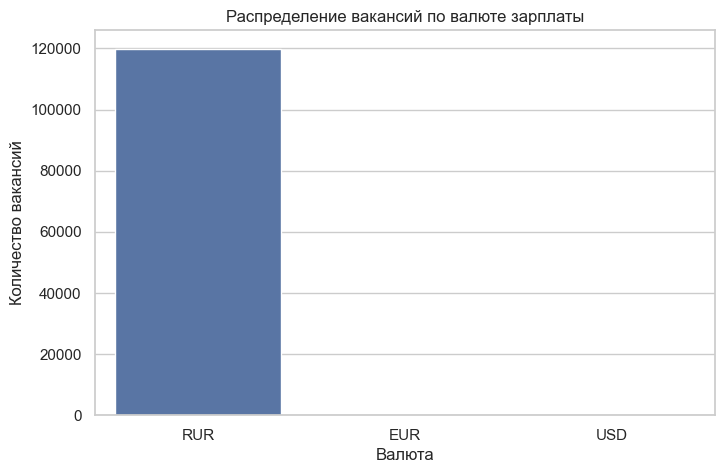

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(color="#4C72B0", data=currency_table, x="currency", y="vacancies_count")
plt.title("Распределение вакансий по валюте зарплаты")
plt.xlabel("Валюта")
plt.ylabel("Количество вакансий")
plt.show()

In [10]:
summary = pd.DataFrame(
    {
        "metric": [
            "Период наблюдений: начало",
            "Период наблюдений: конец",
            "Количество вакансий",
            "Количество уникальных работодателей",
            "Количество городов/регионов",
            "Доля вакансий с рассчитанной зарплатой, %",
            "Медианная salary_mean",
            "Средняя salary_mean",
        ],
        "value": [
            df["published_at"].min(),
            df["published_at"].max(),
            f"{len(df):,}",
            f"{df['employer'].nunique():,}",
            f"{df['area'].nunique():,}",
            round(df["salary_mean_rur"].notna().mean() * 100, 2),
            round(df["salary_mean_rur"].median(), 2),
            round(df["salary_mean_rur"].mean(), 2),
        ],
    }
)

summary

,metric,value
0,Период наблюдений: начало,2025-11-03 09:00:00
1,Период наблюдений: конец,2026-05-03 22:10:35
2,Количество вакансий,"120,000"
3,Количество уникальных работодателей,"1,477"
4,Количество городов/регионов,41
5,"Доля вакансий с рассчитанной зарплатой, %",62.99
6,Медианная salary_mean,"115,000.00"
7,Средняя salary_mean,"129,255.26"


## 6. Распределение вакансий по городам

Город является одним из ключевых факторов рынка труда: он влияет на уровень зарплаты, конкуренцию, формат работы и структуру работодателей.

In [11]:
top_areas = df["area"].value_counts().head(20)
top_areas

area
Москва             30317
Санкт-Петербург    15993
Новосибирск         5332
Удаленно            5229
Екатеринбург        4663
Казань              4419
Нижний Новгород     3639
Краснодар           3636
Самара              3377
Ростов-на-Дону      3145
Уфа                 2828
Воронеж             2710
Пермь               2527
Челябинск           2439
Красноярск          2425
Тюмень              2352
Омск                1957
Волгоград           1757
Иркутск             1639
Сочи                1631
Name: count, dtype: int64

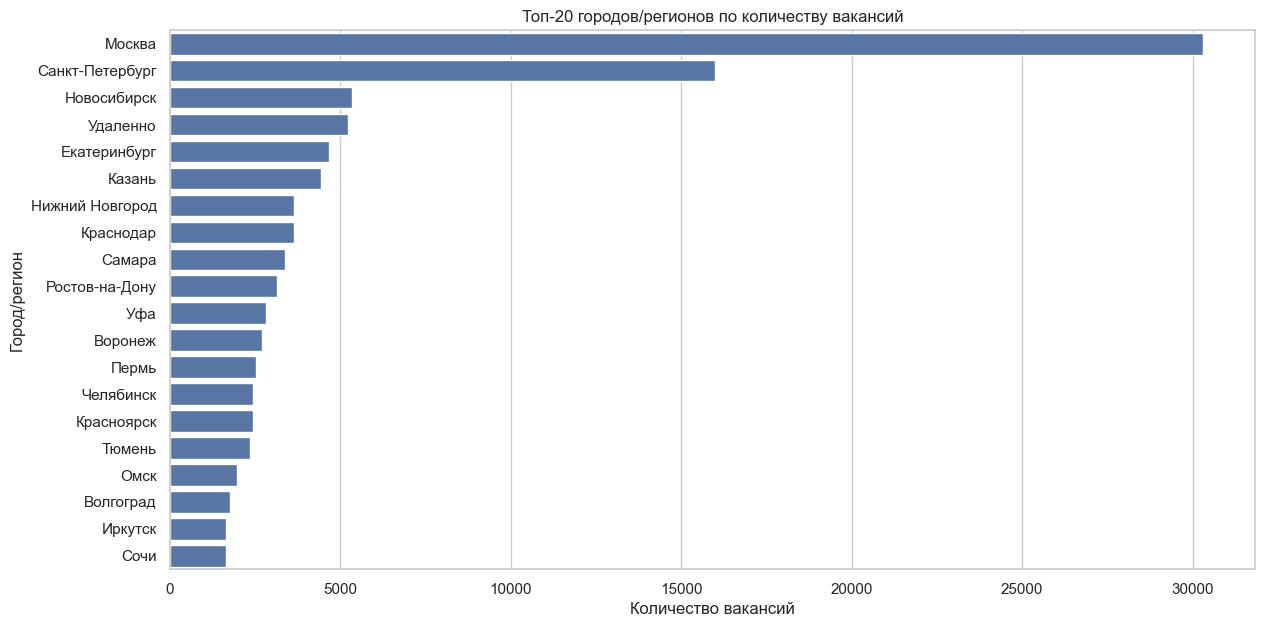

In [12]:
plt.figure(figsize=(14, 7))
sns.barplot(color="#4C72B0", x=top_areas.values, y=top_areas.index)
plt.title("Топ-20 городов/регионов по количеству вакансий")
plt.xlabel("Количество вакансий")
plt.ylabel("Город/регион")
plt.show()

### Вывод

Наибольшее количество вакансий сосредоточено в крупнейших деловых центрах. Лидером является Москва, далее идут Санкт-Петербург и крупные региональные центры. Отдельно выделяется категория «Удаленно», что показывает заметную роль дистанционного формата на рынке юридических вакансий.

## 7. Анализ требований к опыту

Опыт работы — один из наиболее сильных факторов, влияющих на зарплату и содержание вакансии. Сначала посмотрим структуру вакансий по категориям опыта.

In [13]:
experience_order = ["Нет опыта", "От 1 года до 3 лет", "От 3 до 6 лет", "Более 6 лет"]
experience_counts = df["experience"].value_counts().reindex(experience_order)
experience_counts

experience
Нет опыта              8829
От 1 года до 3 лет    51892
От 3 до 6 лет         47143
Более 6 лет           12136
Name: count, dtype: int64

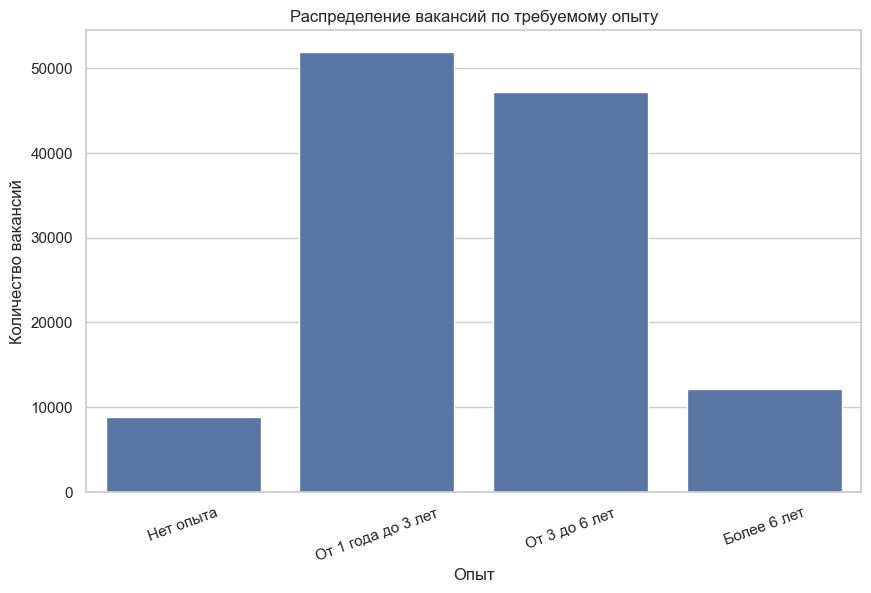

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(color="#4C72B0", x=experience_counts.index, y=experience_counts.values)
plt.title("Распределение вакансий по требуемому опыту")
plt.xlabel("Опыт")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=20)
plt.show()

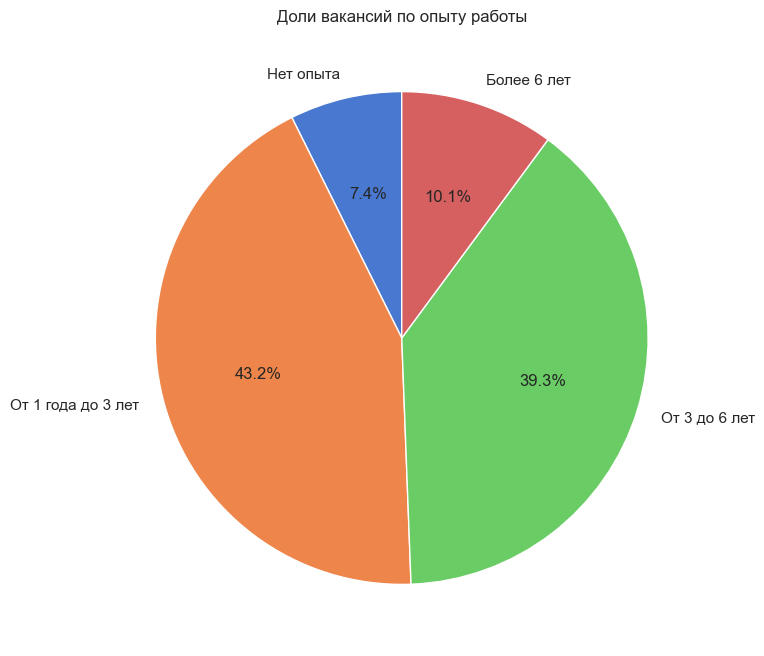

In [15]:
plt.figure(figsize=(8, 8))
experience_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Доли вакансий по опыту работы")
plt.ylabel("")
plt.show()

### Вывод

Основной спрос приходится на специалистов с опытом от 1 до 3 лет и от 3 до 6 лет. Это говорит о том, что рынок преимущественно ориентирован на уже подготовленных кандидатов, которые способны выполнять рабочие задачи без длительного обучения с нуля. Вакансии без опыта также занимают заметную долю, но обычно предполагают более низкий уровень зарплаты и стартовые позиции.

## 8. Тип занятости и график работы

Формат занятости позволяет понять, какие рабочие модели преобладают на рынке: классическая полная занятость, стажировки, проектная работа или частичная занятость.

In [16]:
employment_counts = df["employment"].value_counts()
schedule_counts = df["schedule"].value_counts()

print("Тип занятости:")
display(employment_counts)

print("\nГрафик работы:")
display(schedule_counts)

Тип занятости:


employment
Полная занятость       107388
Частичная занятость      5436
Проектная работа         3715
Стажировка               3461
Name: count, dtype: int64


График работы:


schedule
Полный день         81701
Гибкий график       18457
Удаленная работа    17782
Сменный график       1612
Вахтовый метод        448
Name: count, dtype: int64

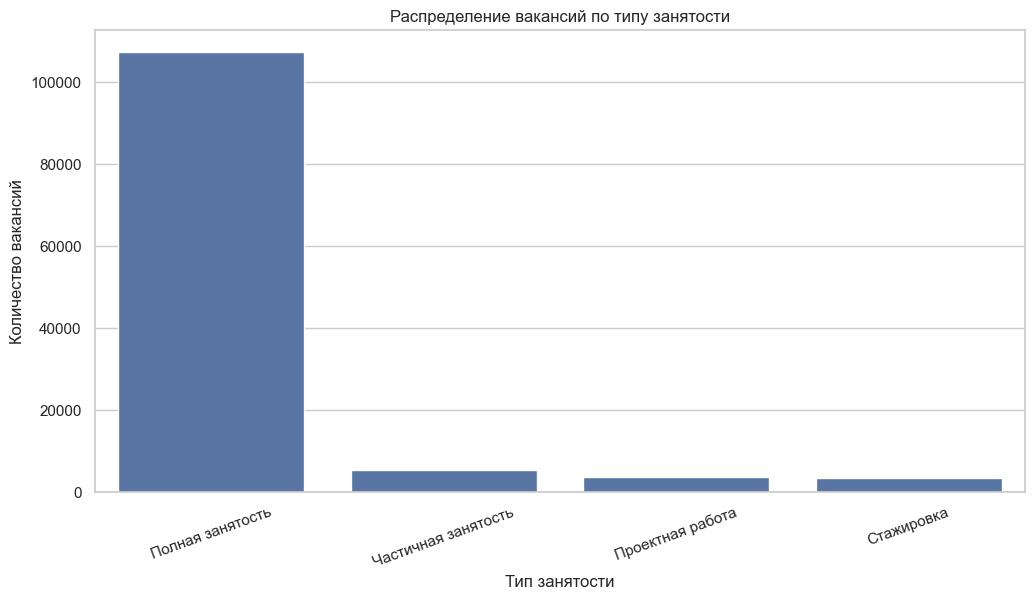

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(color="#4C72B0", x=employment_counts.index, y=employment_counts.values)
plt.title("Распределение вакансий по типу занятости")
plt.xlabel("Тип занятости")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=20)
plt.show()

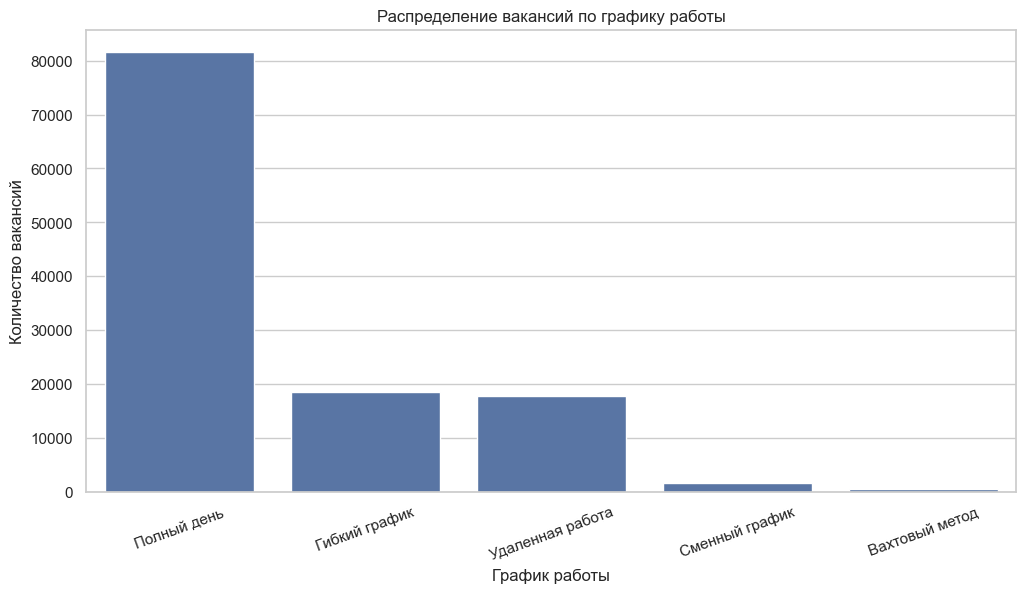

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(color="#4C72B0", x=schedule_counts.index, y=schedule_counts.values)
plt.title("Распределение вакансий по графику работы")
plt.xlabel("График работы")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=20)
plt.show()

### Вывод

На рынке доминирует полная занятость и полный рабочий день. При этом удалённая работа занимает значимую долю, что особенно важно для юридических, договорных, комплаенс- и документооборотных позиций, где часть задач может выполняться дистанционно.

## 9. Анализ зарплатных предложений

Для зарплатного анализа используем только строки, где удалось рассчитать `salary_mean_rur`. При этом важно помнить, что зарплата в вакансиях — это не фактическая зарплата сотрудника, а предложение работодателя. Кроме того, часть работодателей может не указывать зарплату или указывать вилку не полностью.

In [19]:
salary_df = df.dropna(subset=["salary_mean_rur"]).copy()

salary_df[["salary_from", "salary_to", "salary_mean_rur"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,salary_from,salary_to,salary_mean_rur
count,"65,907.00","57,403.00","75,587.00"
mean,"111,497.72","151,607.67","129,255.26"
std,"63,077.26","86,611.66","74,621.64"
min,"20,000.00","25,000.00","20,000.00"
1%,"20,000.00","25,000.00","22,500.00"
5%,"35,000.00","45,000.00","40,000.00"
25%,"65,000.00","90,000.00","77,500.00"
50%,"100,000.00","135,000.00","115,000.00"
75%,"140,000.00","190,000.00","162,500.00"
95%,"230,000.00","320,000.00","270,000.00"


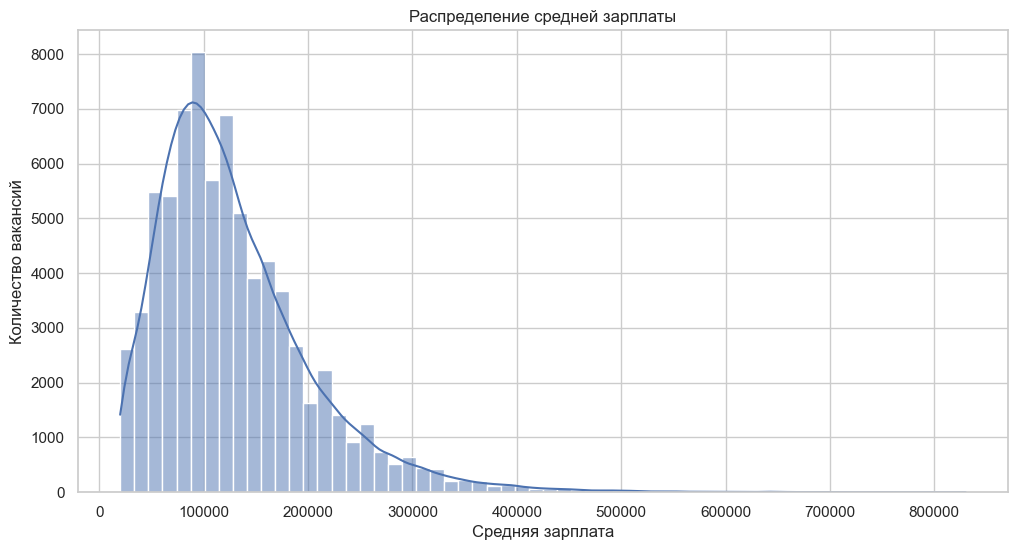

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(x=salary_df["salary_mean_rur"], bins=60, kde=True, color="#4C72B0")
plt.title("Распределение средней зарплаты")
plt.xlabel("Средняя зарплата")
plt.ylabel("Количество вакансий")
plt.show()

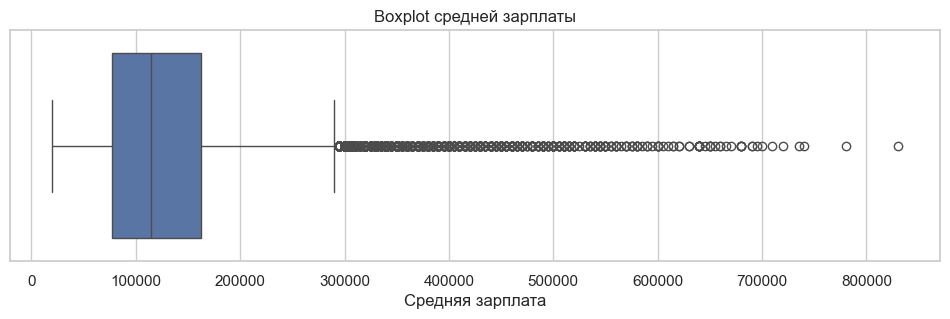

In [21]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=salary_df["salary_mean_rur"], color="#4C72B0")
plt.title("Boxplot средней зарплаты")
plt.xlabel("Средняя зарплата")
plt.show()

### Работа с выбросами

В зарплатных данных почти всегда присутствуют выбросы: очень низкие значения, очень высокие значения, ошибки ввода или вакансии с нестандартной системой оплаты. Для корректной визуализации применим IQR-фильтр. Это не означает, что выбросы «плохие», но для графиков и медианных сравнений их лучше анализировать отдельно.

In [22]:
q1 = salary_df["salary_mean_rur"].quantile(0.25)
q3 = salary_df["salary_mean_rur"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

salary_filtered = salary_df[
    (salary_df["salary_mean_rur"] >= lower_bound) & (salary_df["salary_mean_rur"] <= upper_bound)
].copy()

print(f"Q1: {q1:,.0f}")
print(f"Q3: {q3:,.0f}")
print(f"IQR: {iqr:,.0f}")
print(f"Нижняя граница: {lower_bound:,.0f}")
print(f"Верхняя граница: {upper_bound:,.0f}")
print(f"Удалено как выбросы для визуализации: {len(salary_df) - len(salary_filtered):,} строк")
print(f"Доля выбросов: {(1 - len(salary_filtered) / len(salary_df)) * 100:.2f}%")

Q1: 77,500
Q3: 162,500
IQR: 85,000
Нижняя граница: -50,000
Верхняя граница: 290,000
Удалено как выбросы для визуализации: 2,682 строк
Доля выбросов: 3.55%


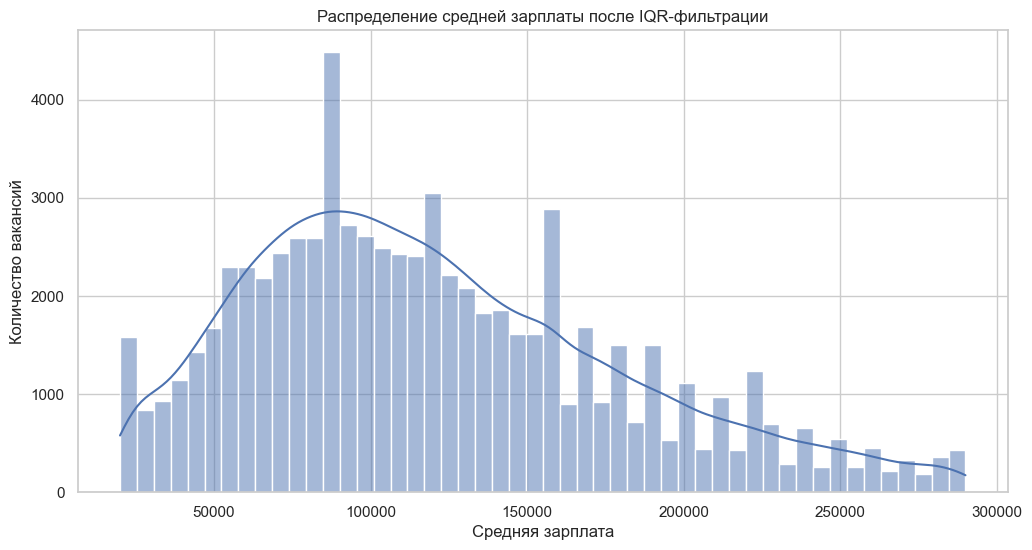

In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(x=salary_filtered["salary_mean_rur"], bins=50, kde=True, color="#4C72B0")
plt.title("Распределение средней зарплаты после IQR-фильтрации")
plt.xlabel("Средняя зарплата")
plt.ylabel("Количество вакансий")
plt.show()

### Вывод

Распределение зарплат имеет правостороннюю асимметрию: большинство вакансий сосредоточено в среднем диапазоне, но присутствует длинный «хвост» высоких зарплат. Поэтому для интерпретации рынка медиана часто надёжнее среднего значения: среднее сильнее реагирует на редкие высокие предложения.

## 10. Зарплата и опыт работы

Проверим, как уровень зарплаты меняется в зависимости от требуемого опыта. Для рынка труда ожидаема положительная связь: чем выше требуемый опыт, тем выше зарплатная вилка.

In [24]:
salary_by_experience = (
    salary_df.groupby("experience")["salary_mean_rur"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reindex(experience_order)
)

salary_by_experience

,count,mean,median,min,max
experience,,,,,
Нет опыта,5654,"58,351.17","50,000.00","20,000.00","345,000.00"
От 1 года до 3 лет,33010,"104,004.70","95,000.00","20,000.00","510,000.00"
От 3 до 6 лет,29470,"151,426.71","137,500.00","20,000.00","735,000.00"
Более 6 лет,7453,"207,213.20","187,500.00","27,500.00","830,000.00"


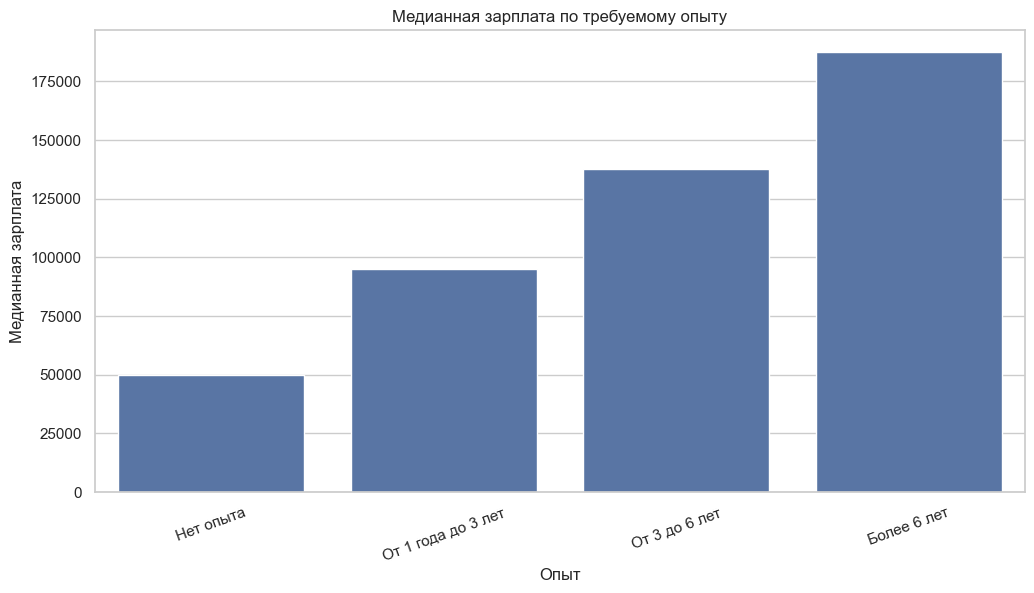

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=salary_by_experience.reset_index(),
    x="experience",
    y="median",
    order=experience_order,
    color="#4C72B0",
)
plt.title("Медианная зарплата по требуемому опыту")
plt.xlabel("Опыт")
plt.ylabel("Медианная зарплата")
plt.xticks(rotation=20)
plt.show()

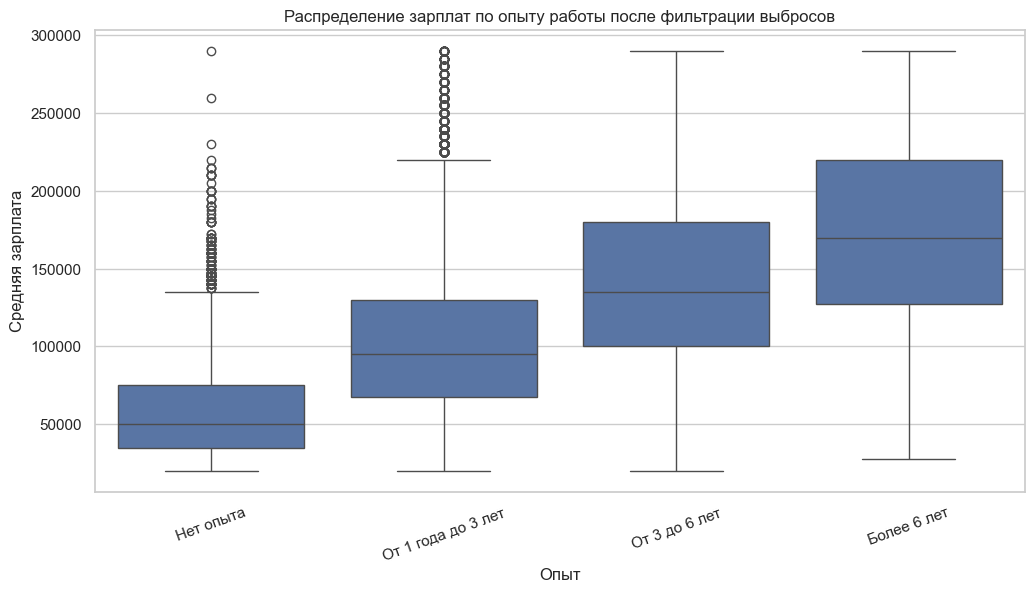

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=salary_filtered,
    x="experience",
    y="salary_mean_rur",
    order=experience_order,
    color="#4C72B0",
)
plt.title("Распределение зарплат по опыту работы после фильтрации выбросов")
plt.xlabel("Опыт")
plt.ylabel("Средняя зарплата")
plt.xticks(rotation=20)
plt.show()

### Вывод

Опыт работы является одним из наиболее очевидных факторов зарплаты. Вакансии для кандидатов без опыта имеют самый низкий медианный уровень оплаты. С ростом требуемого опыта зарплата последовательно увеличивается, а категория «Более 6 лет» формирует наиболее высокий зарплатный сегмент.

## 11. Зарплата по городам и форматам работы

Сравним зарплаты по городам. Для корректности возьмём только города/регионы, где достаточно наблюдений. Это снижает риск выводов на основе единичных вакансий.

In [27]:
area_salary = (
    salary_df.groupby("area")
    .agg(
        vacancies_count=("id", "count"),
        median_salary=("salary_mean_rur", "median"),
        mean_salary=("salary_mean_rur", "mean"),
    )
    .query("vacancies_count >= 100")
    .sort_values("median_salary", ascending=False)
)

area_salary.head(20)

,vacancies_count,median_salary,mean_salary
area,,,
Москва,19132,"160,000.00","176,468.09"
Санкт-Петербург,10070,"135,000.00","146,068.02"
Удаленно,3320,"128,750.00","139,908.89"
Екатеринбург,2914,"110,000.00","118,373.37"
Новосибирск,3383,"107,500.00","116,823.09"
Казань,2730,"105,000.00","115,450.55"
Тюмень,1479,"105,000.00","112,097.70"
Нижний Новгород,2274,"100,000.00","108,358.62"
Краснодар,2312,"100,000.00","109,478.81"


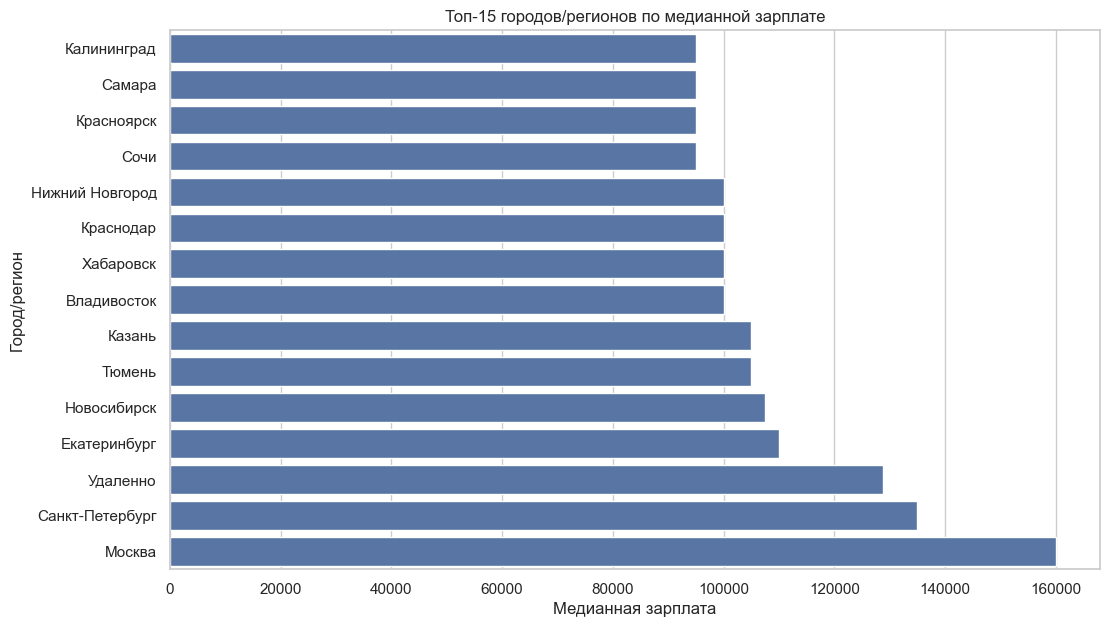

In [28]:
top_area_salary = area_salary.head(15).sort_values("median_salary")

plt.figure(figsize=(12, 7))
sns.barplot(color="#4C72B0", data=top_area_salary, x="median_salary", y=top_area_salary.index)
plt.title("Топ-15 городов/регионов по медианной зарплате")
plt.xlabel("Медианная зарплата")
plt.ylabel("Город/регион")
plt.show()

In [29]:
schedule_salary = (
    salary_df.groupby("schedule")
    .agg(
        vacancies_count=("id", "count"),
        median_salary=("salary_mean_rur", "median"),
        mean_salary=("salary_mean_rur", "mean"),
    )
    .sort_values("median_salary", ascending=False)
)

schedule_salary

,vacancies_count,median_salary,mean_salary
schedule,,,
Удаленная работа,11146,"125,000.00","141,794.14"
Вахтовый метод,273,"115,000.00","129,743.59"
Полный день,51301,"115,000.00","128,837.25"
Сменный график,996,"115,000.00","131,501.00"
Гибкий график,11871,"105,000.00","119,088.96"


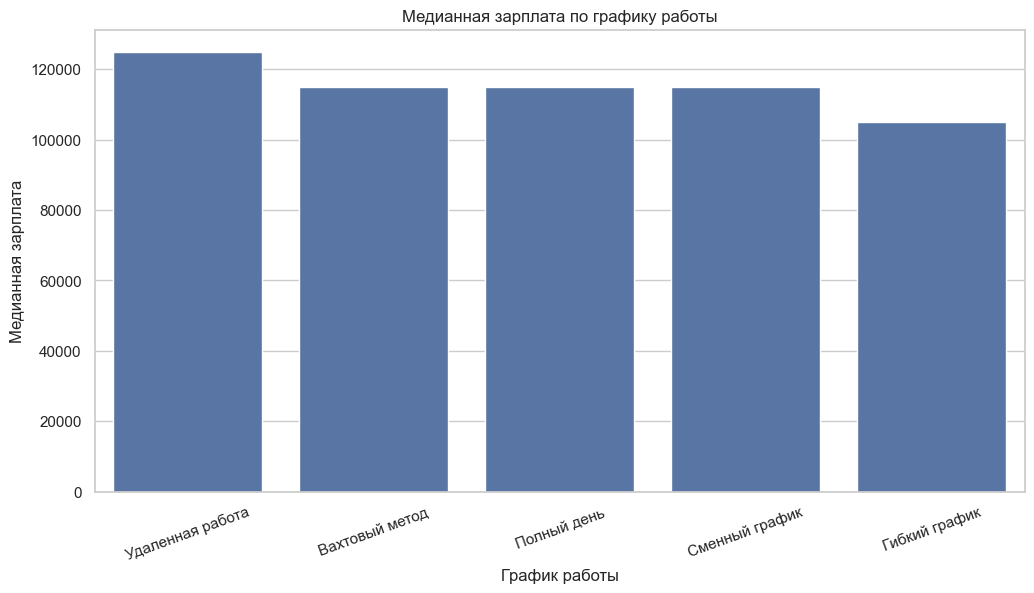

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(color="#4C72B0", data=schedule_salary.reset_index(), x="schedule", y="median_salary")
plt.title("Медианная зарплата по графику работы")
plt.xlabel("График работы")
plt.ylabel("Медианная зарплата")
plt.xticks(rotation=20)
plt.show()

### Вывод

Самые высокие медианные зарплаты ожидаемо наблюдаются в Москве, Санкт-Петербурге и в удалённом формате. Это можно объяснить концентрацией крупных работодателей, более высокой стоимостью труда и конкуренцией за квалифицированных специалистов. Удалённые вакансии также могут быть связаны с более широким географическим рынком и ориентацией на специалистов с более высокой квалификацией.

## 12. Анализ работодателей

Работодатель может сильно влиять на уровень зарплаты и требования к кандидату. Посмотрим, какие компании чаще всего встречаются в датасете.

In [31]:
top_employers = df["employer"].value_counts().head(20)
top_employers

employer
Сбер             7448
ВТБ              4086
Альфа-Банк       2772
Т-Банк           2207
Ozon             1795
Wildberries      1553
Яндекс           1326
VK               1257
МТС              1086
МегаФон           934
Ростелеком        883
Газпром нефть     799
Лукойл            790
РЖД               755
X5 Group          671
Лента             648
Магнит            630
ПИК               567
Самолет           558
Северсталь        546
Name: count, dtype: int64

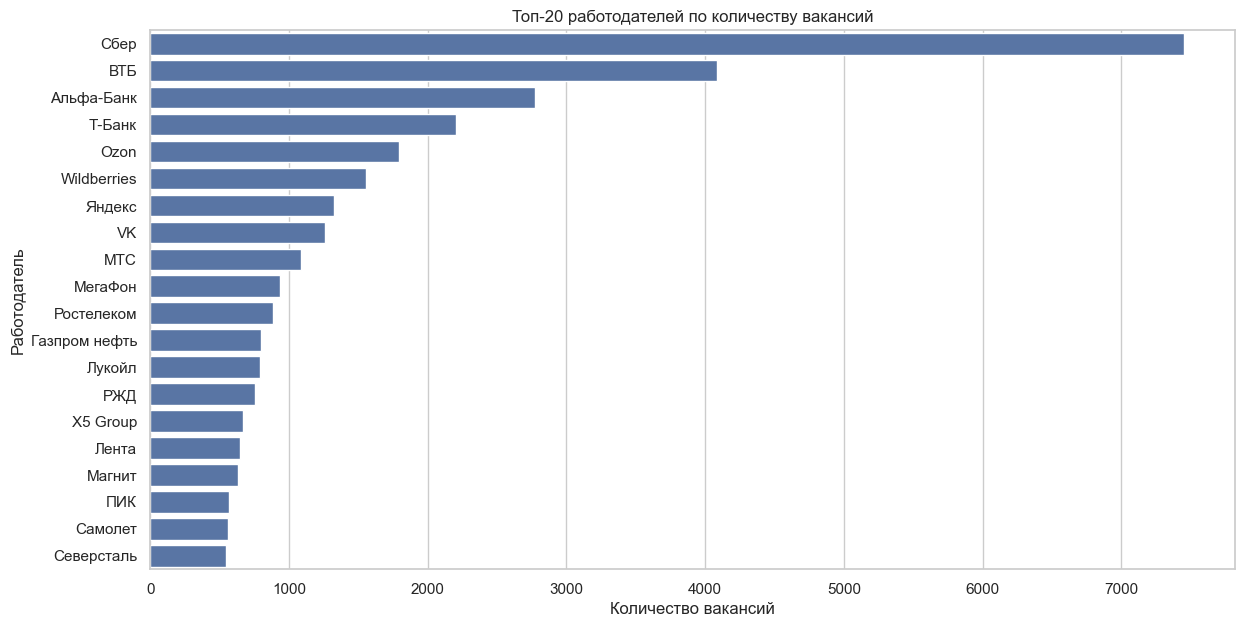

In [32]:
plt.figure(figsize=(14, 7))
sns.barplot(color="#4C72B0", x=top_employers.values, y=top_employers.index)
plt.title("Топ-20 работодателей по количеству вакансий")
plt.xlabel("Количество вакансий")
plt.ylabel("Работодатель")
plt.show()

### Вывод

Топ работодателей показывает, какие компании или группы компаний наиболее активно публикуют вакансии. Однако количество публикаций не всегда означает высокий уровень зарплат: крупные работодатели могут массово размещать как стартовые, так и senior-вакансии. Поэтому для зарплатных выводов работодателей лучше анализировать дополнительно по медиане и числу вакансий.

In [33]:
employer_salary = (
    salary_df.groupby("employer")
    .agg(
        vacancies_count=("id", "count"),
        median_salary=("salary_mean_rur", "median"),
        mean_salary=("salary_mean_rur", "mean"),
    )
    .query("vacancies_count >= 30")
    .sort_values("median_salary", ascending=False)
)

employer_salary.head(20)

,vacancies_count,median_salary,mean_salary
employer,,,
Коллегия адвокатов «Эксперт Технологии Центр»,40,"152,500.00","144,187.50"
Юридическая фирма «Эксперт Строй»,57,"150,000.00","160,657.89"
Банк «Правовой Партнеры»,55,"150,000.00","149,363.64"
Банк «Федеральный Технологии»,34,"147,500.00","143,529.41"
Банк «Капитал Медицина»,54,"146,250.00","144,537.04"
Коллегия адвокатов «Деловой Групп»,40,"145,000.00","142,687.50"
ООО «Новый Проект»,35,"145,000.00","137,000.00"
Коллегия адвокатов «Сибирь Технологии»,48,"143,750.00","159,843.75"
Коллегия адвокатов «Нева Финанс»,82,"142,500.00","146,219.51"


## 13. Анализ ключевых навыков

Ключевые навыки помогают понять, какие компетенции чаще всего ожидают работодатели. Так как в одном поле перечислено несколько навыков через запятую, преобразуем его в «длинный» формат: один навык — одна строка.

In [34]:
skills = df["key_skills"].fillna("").str.split(", ").explode().str.strip()

skills = skills[skills != ""]

skills_counts = skills.value_counts()
print(f"Количество уникальных навыков: {skills_counts.shape[0]:,}")
skills_counts.head(30)

Количество уникальных навыков: 99


key_skills
деловая переписка              25601
правовая экспертиза            23882
работа с документами           22732
MS Office                      20311
переговоры                     20188
ГК РФ                          20093
1С Документооборот             18698
КонсультантПлюс                18539
договорная работа              18300
ЭДО                            17783
Excel                          15829
Гарант                         15768
согласование договоров         13879
претензионная работа           11386
исполнительное производство     7877
договоры                        7705
АПК РФ                          6796
исковая работа                  6756
судебная практика               6154
договоры поставки               5751
протоколы разногласий           5336
корпоративное право             4951
консультирование                4936
персональные данные             4819
суды общей юрисдикции           4417
управление командой             4126
арбитраж                   

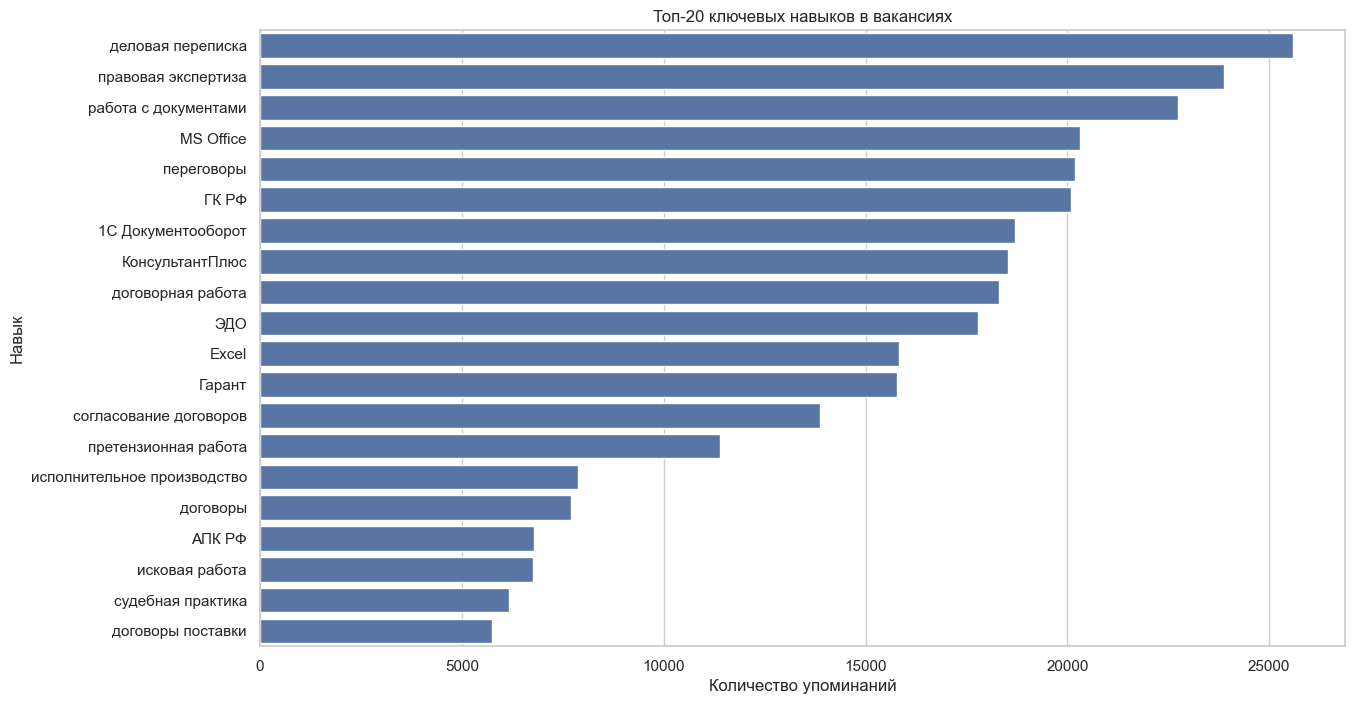

In [35]:
plt.figure(figsize=(14, 8))
sns.barplot(color="#4C72B0", x=skills_counts.head(20).values, y=skills_counts.head(20).index)
plt.title("Топ-20 ключевых навыков в вакансиях")
plt.xlabel("Количество упоминаний")
plt.ylabel("Навык")
plt.show()

### Вывод

В топе навыков находятся компетенции, связанные с договорной работой, претензионной работой, правовой экспертизой, документооборотом, деловой перепиской и переговорами. Это подтверждает, что значительная часть вакансий ориентирована на прикладную юридическую работу с документами, договорами и коммуникацией с контрагентами.

Также встречаются навыки, связанные с `Excel`, `MS Office`, legal English, закупками, 44-ФЗ, 223-ФЗ, арбитражем и процессуальными документами. Это показывает, что работодатели ценят не только юридическую базу, но и прикладные офисные, аналитические и коммуникационные навыки.

## 14. NLP-анализ текстов вакансий

После анализа отдельных ключевых навыков расширим исследование с помощью методов NLP. В текстовый корпус объединим название вакансии и список ключевых навыков. Это позволит анализировать не только отдельные компетенции, но и смысловые сочетания слов, например «договорная работа», «претензионная работа», «арбитражный суд», «44-ФЗ», «legal english» и другие устойчивые требования работодателей.

**Зачем добавляем NLP:** обычный подсчёт навыков показывает, какие слова встречаются чаще всего, но не всегда раскрывает смысловые группы вакансий. NLP помогает перейти от простого списка навыков к анализу содержания вакансий.

**Цель NLP-блока:** выделить наиболее важные термины, сгруппировать вакансии по текстовому сходству и проверить, отличаются ли такие группы по уровню зарплаты.


In [36]:
# Объединяем текстовые признаки в единый корпус для NLP-анализа.
df["text_nlp"] = (df["name"].fillna("") + " " + df["key_skills"].fillna("")).str.lower()

# Исключаем строки, где после объединения нет текстовой информации.
nlp_df = df[df["text_nlp"].str.strip() != ""].copy()

nlp_df[["name", "key_skills", "text_nlp"]].head()

,name,key_skills,text_nlp
0,Юрисконсульт по правовому сопровождению,"работа с документами, консультирование, ГК РФ, 1С Документооборот, переговоры","юрисконсульт по правовому сопровождению работа с документами, консультирование, гк рф, 1с документооборот, переговоры"
1,Помощник юриста,"оферты, ЭДО, Гарант, архив документов, переговоры, MS Office","помощник юриста оферты, эдо, гарант, архив документов, переговоры, ms office"
2,Помощник юриста,"Excel, архив документов, ЭДО, банкротство","помощник юриста excel, архив документов, эдо, банкротство"
3,Корпоративный юрист,"корпоративное право, протоколы собраний, ЕГРЮЛ, M&A, MS Office, Гарант","корпоративный юрист корпоративное право, протоколы собраний, егрюл, m&a, ms office, гарант"
4,Младший юрист,"Гарант, ГК РФ, деловая переписка, переговоры","младший юрист гарант, гк рф, деловая переписка, переговоры"


**Краткий вывод по подготовке текста:** для каждой вакансии создано единое поле `text_nlp`, где объединены название вакансии и ключевые навыки. Это поле будет использоваться как текстовая основа для всех следующих NLP-этапов. Пустые тексты исключены, чтобы модель работала только с информативными наблюдениями.


### 14.1. Выделение важных терминов с помощью TF-IDF

**Что делаем:** преобразуем текст вакансий в числовую матрицу TF-IDF. В анализ включаются отдельные слова и пары слов (`ngram_range=(1, 2)`), чтобы учитывать не только одиночные термины, но и устойчивые словосочетания.

**Зачем это нужно:** TF-IDF помогает найти слова и фразы, которые лучше всего характеризуют вакансии. В отличие от простого подсчёта частот, метод снижает вес слишком общих слов и повышает значимость терминов, которые сильнее отличают одни вакансии от других.


In [37]:
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=5)

X_tfidf = tfidf.fit_transform(nlp_df["text_nlp"])

terms = pd.DataFrame(
    {"term": tfidf.get_feature_names_out(), "mean_tfidf": np.asarray(X_tfidf.mean(axis=0)).ravel()}
).sort_values("mean_tfidf", ascending=False)

terms.head(30)

,term,mean_tfidf
1434,юрист,0.07
1015,работа,0.05
841,по,0.04
1472,юрист по,0.04
1110,рф,0.03
294,деловая,0.03
295,деловая переписка,0.03
789,переписка,0.03
729,отдела,0.03
922,правовая,0.03


**Краткий вывод по TF-IDF:** таблица показывает наиболее значимые термины в текстах вакансий. Эти слова и словосочетания можно использовать для интерпретации рынка: они отражают основные требования работодателей и помогают понять, какие направления юридической работы чаще всего встречаются в вакансиях.


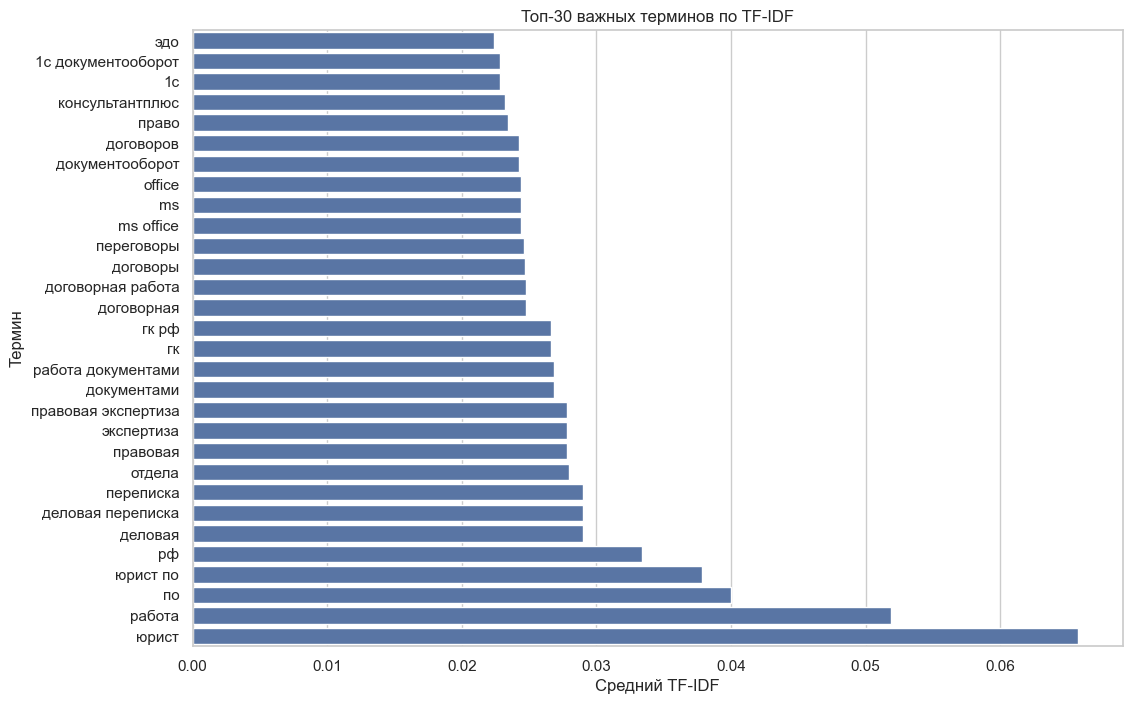

In [38]:
top_terms = terms.head(30).sort_values("mean_tfidf")

plt.figure(figsize=(12, 8))
sns.barplot(data=top_terms, x="mean_tfidf", y="term", color="#4C72B0")
plt.title("Топ-30 важных терминов по TF-IDF")
plt.xlabel("Средний TF-IDF")
plt.ylabel("Термин")
plt.show()

**Краткий вывод по визуализации TF-IDF:** график наглядно показывает топ терминов по среднему TF-IDF. Самые высокие значения получают слова и фразы, которые часто встречаются в важных контекстах и помогают описать специфику юридических вакансий.


### 14.2. Кластеризация вакансий по текстовому содержанию

**Что делаем:** группируем вакансии на основе текстового сходства с помощью алгоритма KMeans. На вход модели подаётся TF-IDF-матрица, то есть числовое представление текста.

**Зачем это нужно:** кластеризация позволяет автоматически выделить тематические группы вакансий без ручной разметки. Например, могут появиться группы, связанные с договорной работой, судебной практикой, закупками, комплаенсом, помощниками юриста или корпоративным правом.


In [39]:
# Проверим несколько вариантов числа кластеров с помощью silhouette score.
# Чем выше значение, тем лучше объекты отделены друг от друга.
cluster_scores = []

for k in range(3, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, labels)
    cluster_scores.append({"n_clusters": k, "silhouette_score": score})

cluster_scores = pd.DataFrame(cluster_scores)
cluster_scores

,n_clusters,silhouette_score
0,3,0.03
1,4,0.03
2,5,0.04
3,6,0.05
4,7,0.05
5,8,0.06


**Краткий вывод по выбору числа кластеров:** рассчитан `silhouette_score` для нескольких вариантов количества кластеров. Этот показатель помогает оценить, насколько хорошо вакансии разделяются на группы. Чем выше значение, тем более отделёнными являются кластеры.


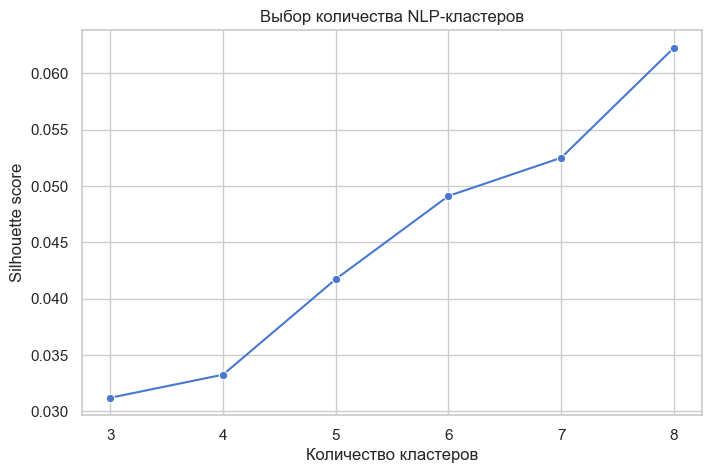

In [40]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=cluster_scores, x="n_clusters", y="silhouette_score", marker="o")
plt.title("Выбор количества NLP-кластеров")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette score")
plt.show()

**Краткий вывод по графику silhouette score:** график помогает выбрать разумное количество кластеров. В проекте далее используется 6 кластеров, потому что такое число удобно интерпретировать и позволяет получить несколько содержательных групп вакансий.


In [41]:
# Для интерпретируемости выберем 6 кластеров.
n_clusters = 6

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

nlp_df["nlp_cluster"] = kmeans.fit_predict(X_tfidf)

# Переносим кластер обратно в основной датафрейм.
df = df.merge(nlp_df[["id", "nlp_cluster"]], on="id", how="left")

nlp_df[["name", "key_skills", "nlp_cluster"]].head()

,name,key_skills,nlp_cluster
0,Юрисконсульт по правовому сопровождению,"работа с документами, консультирование, ГК РФ, 1С Документооборот, переговоры",3
1,Помощник юриста,"оферты, ЭДО, Гарант, архив документов, переговоры, MS Office",0
2,Помощник юриста,"Excel, архив документов, ЭДО, банкротство",0
3,Корпоративный юрист,"корпоративное право, протоколы собраний, ЕГРЮЛ, M&A, MS Office, Гарант",0
4,Младший юрист,"Гарант, ГК РФ, деловая переписка, переговоры",0


**Краткий вывод по присвоению кластеров:** каждой вакансии присвоен номер NLP-кластера. Новый признак `nlp_cluster` можно использовать не только для анализа, но и как дополнительный категориальный признак в будущей модели прогнозирования зарплаты.


In [51]:
# Посмотрим, какие термины наиболее характерны для каждого кластера.
feature_names = np.array(tfidf.get_feature_names_out())

for cluster_id in range(n_clusters):
    center = kmeans.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-15:][::-1]
    top_words = feature_names[top_indices]

    print(f"\nКластер {cluster_id}")
    print(", ".join(top_words))


Кластер 0
юридического, корпоративный, корпоративный юрист, юридического отдела, право, юрист, младший, младший юрист, ms, ms office, office, переписка, деловая переписка, деловая, налоговый юрист

Кластер 1
договоров, согласование договоров, согласование, работа, договорная, договорная работа, гк, гк рф, договорного, договорного отдела, юрист, рф, отдела, специалист договорного, специалист

Кластер 2
юрист по, по, юрист, недвижимости, по недвижимости, праву, фз, право, трудовому, трудовому праву, по трудовому, интеллектуальной собственности, собственности, интеллектуальной, по интеллектуальной

Кластер 3
юрисконсульт, консультирование, юрисконсульт договорного, гк, гк рф, правовому сопровождению, правовому, сопровождению, юрисконсульт по, по правовому, договоры, экспертиза, правовая, правовая экспертиза, договорного

Кластер 4
ведущий юрист, ведущий, старший юрист, старший, legal, работа, судебная, юрист, управление, договорная, договорная работа, экспертиза, правовая, правовая экспе

**Краткий вывод по интерпретации кластеров:** список характерных терминов помогает дать смысловое название каждому кластеру. Например, если в кластере много слов «договор», «контрагент», «экспертиза», его можно интерпретировать как группу вакансий по договорной работе.


In [43]:
# Примеры вакансий из каждого кластера.
for cluster_id in range(n_clusters):
    print(f"\n=== Кластер {cluster_id} ===")
    display(
        nlp_df[nlp_df["nlp_cluster"] == cluster_id][
            ["name", "area", "employer", "key_skills"]
        ].head(10)
    )


=== Кластер 0 ===


,name,area,employer,key_skills
1,Помощник юриста,Удаленно,Альфа-Банк,"оферты, ЭДО, Гарант, архив документов, переговоры, MS Office"
2,Помощник юриста,Нижний Новгород,МФК «Проф Технологии»,"Excel, архив документов, ЭДО, банкротство"
3,Корпоративный юрист,Нижний Новгород,Юридическая фирма «Правовой Медицина»,"корпоративное право, протоколы собраний, ЕГРЮЛ, M&A, MS Office, Гарант"
4,Младший юрист,Екатеринбург,ВТБ,"Гарант, ГК РФ, деловая переписка, переговоры"
10,Помощник юриста,Омск,Альфа-Банк,"банкротство, архив документов, MS Office, деловая переписка, работа с документами"
12,Младший юрист,Новосибирск,Коллегия адвокатов «Проф Консалт»,"деловая переписка, Excel, работа с документами, ГК РФ"
23,Корпоративный юрист,Санкт-Петербург,Банк «Север Сервис»,"ЕГРЮЛ, M&A, протоколы собраний, корпоративное право"
25,Ассистент юридического отдела,Санкт-Петербург,Юридическая фирма «Капитал Финанс»,"КонсультантПлюс, переговоры, деловая переписка, документооборот"
35,Налоговый юрист,Санкт-Петербург,ГК «Федеральный Право»,NaN
37,Налоговый юрист,Краснодар,Юридическая фирма «Федеральный Строй М»,NaN



=== Кластер 1 ===


,name,area,employer,key_skills
13,Юрист общего профиля,Москва,Альфа-Банк,"правовая экспертиза, ГК РФ, MS Office"
14,Юрист по согласованию договоров,Москва,ЭнергоСервис,"оферты, КонсультантПлюс, ГК РФ, согласование договоров, протоколы разногласий, договоры поставки, GDPR"
19,Юрист по согласованию договоров,Иркутск,Яндекс,NaN
22,Юрист по договорной работе,Удаленно,ГК «Север Ресурс»,"работа с документами, MS Office, ЭДО, Excel, договоры поставки"
30,Договорной юрист,Оренбург,ПИК,"протоколы разногласий, договоры поставки, согласование договоров, ГК РФ"
34,Специалист договорного отдела,Казань,Банк «Урал Девелопмент»,"переговоры, деловая переписка, Гарант, согласование договоров"
42,Юрист в компанию,Самара,Ozon,"претензионная работа, деловая переписка, согласование договоров, NDA, договорная работа"
57,Юрист общего профиля,Самара,Коллегия адвокатов «Правовой Право Плюс»,"согласование договоров, договорная работа, Excel"
65,Юрист,Удаленно,ГК «Правовой Право»,"согласование договоров, деловая переписка, ЭДО, договорная работа"
68,Юрист по согласованию договоров,Москва,ООО «Деловой Логистика»,NaN



=== Кластер 2 ===


...

,name,area,employer,key_skills
0,Юрисконсульт по правовому сопровождению,Москва,ООО «Деловой Проект»,"работа с документами, консультирование, ГК РФ, 1С Документооборот, переговоры"
26,Юрисконсульт,Ставрополь,Коллегия адвокатов «Деловой Право»,"ГК РФ, Excel, работа с документами, 1С Документооборот, консультирование"
28,Юрисконсульт договорного отдела,Самара,Т-Банк,"договоры, консультирование, ЭДО"
29,Юрисконсульт,Нижний Новгород,ПАО «Техно Проект Плюс»,"ЭДО, работа с документами, правовая экспертиза, консультирование, ГК РФ, договоры"
63,Юрисконсульт,Москва,Коллегия адвокатов «Федеральный Инвест Плюс»,"Гарант, ГК РФ, Excel, договоры"
66,Юрисконсульт договорного отдела,Екатеринбург,ООО «Эксперт Строй»,"консультирование, правовая экспертиза"
117,Юрисконсульт по правовому сопровождению,Москва,ВТБ,"1С Документооборот, MS Office, Excel, работа с документами, консультирование, договоры"
144,Юрисконсульт договорного отдела,Санкт-Петербург,ООО «Нева Строй М»,"КЭДО, переговоры, договоры, MS Office, ГК РФ"
171,Юрисконсульт,Челябинск,ГК «Правовой Инвест»,"договоры, ГК РФ"
182,Юрисконсульт договорного отдела,Оренбург,Коллегия адвокатов «Нева Партнеры СПб»,NaN



=== Кластер 4 ===


,name,area,employer,key_skills
11,Старший юрист,Новосибирск,МТС,"судебная практика, управление командой, деловая переписка, договорная работа"
24,Старший юрист (удаленно),Удаленно,ПАО «Эксперт Право»,"договорная работа, 1С Документооборот, работа с документами"
40,Ведущий юрист,Удаленно,Банк «Федеральный Консалт»,"работа с документами, управление проектами, КонсультантПлюс, деловая переписка, правовая экспертиза, MS Office, пере..."
47,Ведущий юрист,Санкт-Петербург,ПАО «Эксперт Трейд»,"правовая экспертиза, судебная работа, управление проектами"
50,Старший юрист,Москва,Коллегия адвокатов «Федеральный Медицина»,"Гарант, Excel, правовая экспертиза, переговоры, MS Office, управление командой"
62,Ведущий юрист,Москва,ИП «Правовой Инвест»,"MS Office, договорная работа, деловая переписка, КонсультантПлюс, Гарант, судебная работа, Excel, ЭДО"
77,Ведущий юрист,Тюмень,АО «Нева Финанс СПб»,"правовая экспертиза, переговоры, деловая переписка, договорная работа, воинский учет"
87,Ведущий юрист,Томск,Норникель,"договорная работа, правовая экспертиза, ЭДО, судебная работа"
90,Ведущий юрист (удаленно),Удаленно,Юридическая фирма «Сибирь Партнеры»,"переговоры, управление проектами, правовая экспертиза"
92,Старший юрист,Новосибирск,Коллегия адвокатов «Проф Технологии»,"переговоры, деловая переписка, договорная работа, управление командой, правовая экспертиза"



=== Кластер 5 ===


,name,area,employer,key_skills
16,Юрист по взысканию задолженности,Москва,Коллегия адвокатов «Проф Медицина»,"исполнительное производство, MS Office, Excel, правовая экспертиза, ФССП, претензионная работа, взыскание задолженности"
20,Арбитражный юрист,Омск,Юридическая фирма «Правовой Технологии»,NaN
32,Арбитражный юрист,Томск,Коллегия адвокатов «Капитал Проект»,"исковая работа, ЭДО, судебная практика"
38,Арбитражный юрист,Удаленно,Юридическая фирма «Эксперт Технологии»,"арбитраж, 1С Документооборот, судебная практика, АПК РФ"
46,Арбитражный юрист,Санкт-Петербург,ПАО «Правовой Групп Про»,"судебная практика, работа с документами, АПК РФ, арбитраж"
69,Арбитражный юрист,Казань,Юридическая фирма «Техно Право»,"переговоры, арбитраж, АПК РФ, исковая работа, исполнительное производство, воинский учет"
71,Арбитражный юрист,Нижний Новгород,Коллегия адвокатов «Правовой Групп»,"исковая работа, арбитраж, 1С Документооборот, судебная практика"
80,Юрист по взысканию задолженности,Уфа,Коллегия адвокатов «Эксперт Логистика»,"работа с документами, ФССП, правовая экспертиза, претензионная работа, Гарант, персональные данные"
82,Арбитражный юрист,Санкт-Петербург,Юридическая фирма «Правовой Ресурс»,"Excel, АПК РФ, исковая работа, исполнительное производство"
83,Юрист по судебной работе,Воронеж,Коллегия адвокатов «Эксперт Технологии М»,"суды общей юрисдикции, исполнительное производство"


**Краткий вывод по примерам вакансий:** просмотр реальных вакансий внутри каждого кластера нужен для проверки интерпретации. Если примеры вакансий похожи по смыслу, значит кластеризация сработала логично и может использоваться в выводах проекта.


### 14.3. Зарплаты по NLP-кластерам

**Что делаем:** сравниваем медианную и среднюю зарплату между NLP-кластерами.

**Зачем это нужно:** после выделения тематических групп можно проверить, связана ли специализация вакансии с уровнем зарплаты. Это помогает понять, какие направления юридической работы потенциально оплачиваются выше.


In [44]:
salary_by_nlp_cluster = (
    nlp_df.dropna(subset=["salary_mean_rur"])
    .groupby("nlp_cluster")
    .agg(
        vacancies_count=("id", "count"),
        median_salary=("salary_mean_rur", "median"),
        mean_salary=("salary_mean_rur", "mean"),
    )
    .sort_values("median_salary", ascending=False)
)

salary_by_nlp_cluster

,vacancies_count,median_salary,mean_salary
nlp_cluster,,,
4,8649,"160,000.00","175,384.44"
2,18328,"125,000.00","137,814.55"
5,9990,"115,000.00","128,431.43"
1,15630,"105,000.00","115,826.62"
3,6246,"102,500.00","113,772.41"
0,16744,"87,500.00","114,860.85"


**Краткий вывод по таблице зарплат:** таблица показывает количество вакансий и зарплатные показатели внутри каждого NLP-кластера. Для интерпретации лучше ориентироваться на медиану, так как она меньше зависит от редких очень высоких или очень низких значений.


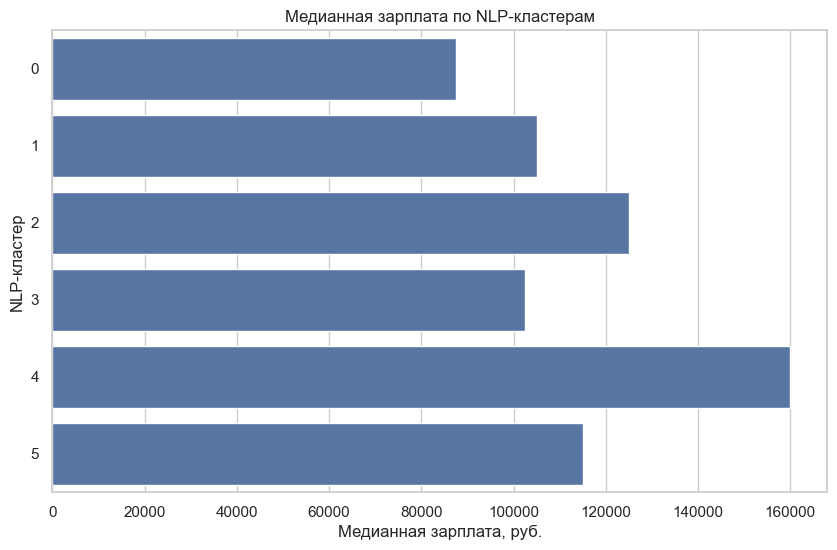

In [45]:
salary_cluster_plot = salary_by_nlp_cluster.sort_values("median_salary")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=salary_cluster_plot.reset_index(),
    x="median_salary",
    y="nlp_cluster",
    orient="h",
    color="#4C72B0",
)
plt.title("Медианная зарплата по NLP-кластерам")
plt.xlabel("Медианная зарплата, руб.")
plt.ylabel("NLP-кластер")
plt.show()

**Краткий вывод по графику зарплат:** визуализация позволяет быстро сравнить NLP-кластеры между собой. Если один из кластеров имеет заметно более высокую медианную зарплату, это означает, что содержание вакансии и её специализация могут быть важным фактором уровня оплаты.


### 14.4. Визуализация текстовых кластеров

**Что делаем:** снижаем размерность TF-IDF-матрицы до двух компонент с помощью TruncatedSVD и строим scatter plot.

**Зачем это нужно:** исходная TF-IDF-матрица содержит много признаков, поэтому её нельзя напрямую показать на двумерном графике. TruncatedSVD позволяет получить упрощённую 2D-карту, на которой можно визуально оценить структуру кластеров.


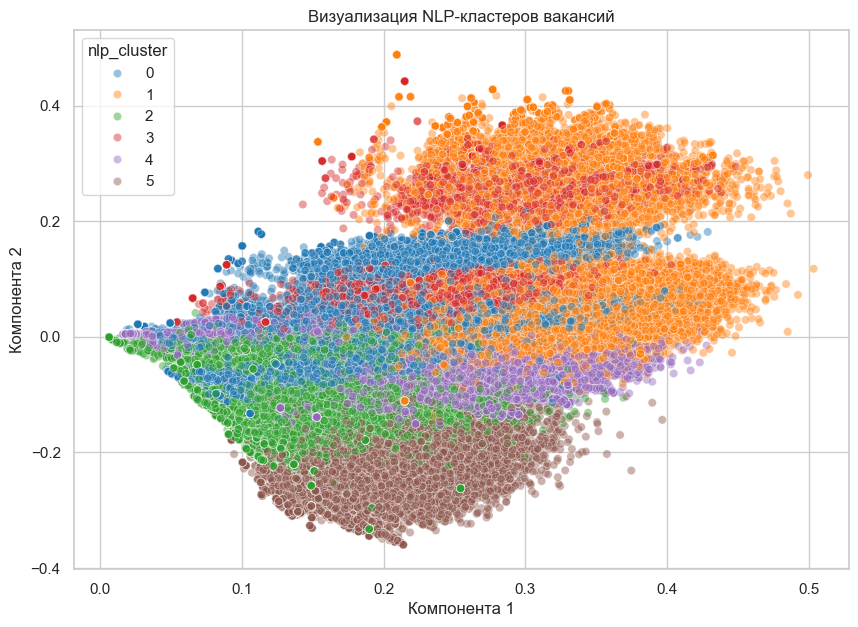

In [46]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

nlp_df["x_nlp"] = X_2d[:, 0]
nlp_df["y_nlp"] = X_2d[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=nlp_df,
    x="x_nlp",
    y="y_nlp",
    hue="nlp_cluster",
    palette="tab10",
    alpha=0.45,
    legend="full",
)
plt.title("Визуализация NLP-кластеров вакансий")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.show()

**Краткий вывод по визуализации кластеров:** точки на графике — это отдельные вакансии, а цвет показывает NLP-кластер. Если точки одного цвета частично группируются вместе, значит тексты вакансий действительно имеют смысловое сходство. Такая визуализация помогает показать результат NLP-анализа на защите проекта.


### Итоговый вывод по NLP-блоку

NLP-анализ дополнил обычный подсчёт ключевых навыков. С помощью TF-IDF удалось выделить наиболее характерные термины и словосочетания, а кластеризация позволила разделить вакансии на несколько тематических групп. Такие группы можно использовать как дополнительный аналитический признак и как потенциальный фактор для будущей модели прогнозирования зарплаты.

Сравнение медианных зарплат по NLP-кластерам показывает, что содержание вакансии связано с уровнем оплаты: разные типы юридических ролей могут иметь разные зарплатные диапазоны даже внутри одного профессионального рынка.


## 15. Временная динамика публикаций

Проанализируем, как распределяются вакансии по месяцам и дням недели. Это помогает увидеть активность работодателей во времени.

In [47]:
monthly_publications = df.set_index("published_at").resample("ME")["id"].count()
monthly_publications

published_at
2025-11-30     3132
2025-12-31     3497
2026-01-31     7200
2026-02-28    12577
2026-03-31    28929
2026-04-30    57989
2026-05-31     6676
Freq: ME, Name: id, dtype: int64

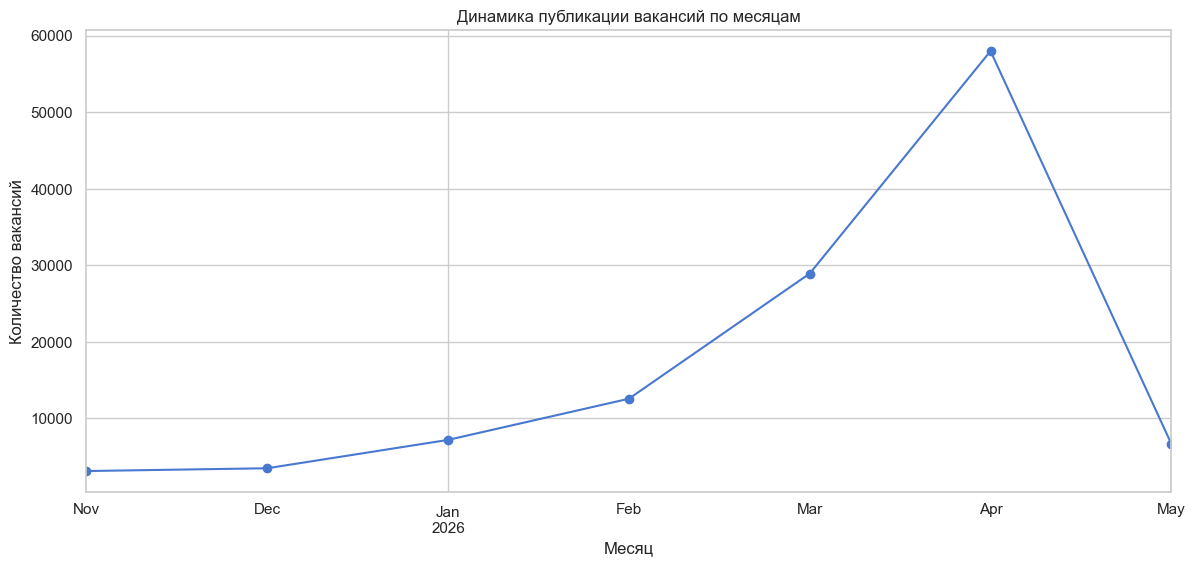

In [48]:
plt.figure(figsize=(14, 6))
monthly_publications.plot(marker="o")
plt.title("Динамика публикации вакансий по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество вакансий")
plt.show()

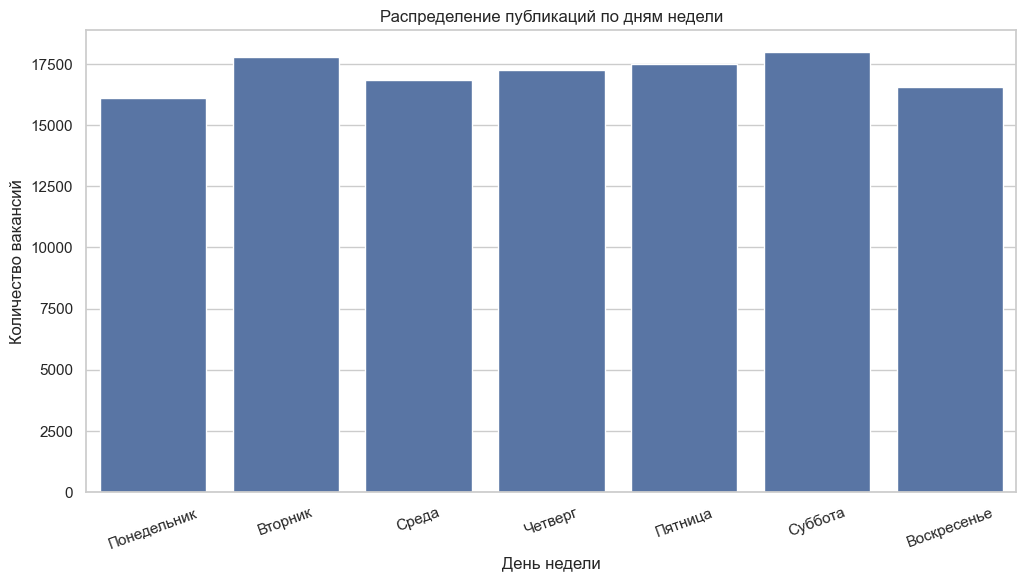

In [49]:
day_order = ["Понедельник", "Вторник", "Среда", "Четверг", "Пятница", "Суббота", "Воскресенье"]
day_counts = df["published_day_name"].value_counts().reindex(day_order)

plt.figure(figsize=(12, 6))
sns.barplot(color="#4C72B0", x=day_counts.index, y=day_counts.values)
plt.title("Распределение публикаций по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=20)
plt.show()

### Вывод

Временная динамика позволяет оценить стабильность сбора данных и сезонность публикаций. Если в отдельные месяцы наблюдаются резкие пики или провалы, это может быть связано как с реальной активностью рынка, так и с особенностями периода сбора данных.

## 16. Итоговые выводы

По результатам анализа можно сделать следующие выводы.

### 1. Датасет пригоден для анализа

В таблице нет дубликатов по `id`, структура данных понятна, основные категориальные признаки заполнены. Главная зона пропусков — зарплатные вилки, что является нормальной особенностью вакансий с HH.ru.

### 2. Основной рынок сосредоточен в крупных городах

Больше всего вакансий приходится на Москву, Санкт-Петербург и крупные региональные центры. Отдельно заметна категория удалённой работы, что показывает развитие дистанционного формата.

### 3. Опыт работы существенно связан с зарплатой

Зарплатный уровень последовательно растёт от вакансий без опыта к вакансиям для специалистов с опытом более 6 лет. Это один из самых интерпретируемых факторов зарплаты.

### 4. Полная занятость и полный день остаются доминирующими

Большинство вакансий ориентировано на классический формат занятости. При этом удалённый и гибкий форматы занимают заметную долю и могут быть важными признаками для модели.

### 5. Ключевые навыки отражают прикладной юридический профиль вакансий

Наиболее востребованы договорная работа, претензионная работа, правовая экспертиза, работа с документами, деловая переписка, переговоры, Excel и MS Office. Это показывает, что работодателям нужны специалисты, способные работать не только с нормами права, но и с документами, коммуникацией и офисными инструментами.


### 6. NLP-анализ позволил выделить тематические группы вакансий

Объединение названий вакансий и ключевых навыков в единый текстовый корпус позволило применить TF-IDF и кластеризацию. В результате вакансии были разделены на тематические группы, которые отражают разные направления юридической работы: договорную, судебную, корпоративную, закупочную, комплаенс- и административно-документарную. Сравнение зарплат по NLP-кластерам показывает, что не только город и опыт, но и содержание вакансии может быть связано с уровнем оплаты.


# Финальное резюме проекта

В проекте проведён полный цикл первичного анализа данных: загрузка, проверка качества, предобработка, исследовательский анализ, анализ зарплат, навыков, работодателей, форматов работы и NLP-анализ текстового содержания вакансий.

Главный практический результат проекта — понимание факторов, связанных с зарплатой в юридических вакансиях: опыт работы, город, формат занятости, удалённость, работодатель, набор ключевых навыков и тематический NLP-кластер вакансии. Такой анализ может использоваться как основа для карьерной аналитики, мониторинга рынка труда и построения рекомендательной или прогнозной системы по вакансиям.